# Rubin ToO Workshop: Simulating a Single Kilonova Event

We will:
- load one injected event from a JSON file,
- select Rubin visits near the event sky position,
- simulate light curves with `lightcurvelynx` and `redback`,
- keep the best attempt that reaches the requested detection threshold,
- save observation tables and a plot for discussion during the workshop.


In [23]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.cosmology import FlatLambdaCDM, z_at_value

from IPython.display import Image, display

from lightcurvelynx.obstable.ztf_obstable import ZTFObsTable
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.models.redback_models import RedbackWrapperModel
from lightcurvelynx.simulate import simulate_lightcurves
from redback.transient_models.kilonova_models import bulla_bns_kilonova

mpl.rcParams["text.usetex"] = False
mpl.rcParams["figure.figsize"] = (13, 6)
mpl.rcParams["axes.grid"] = False
import matplotlib as mpl

mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["DejaVu Serif"]
import logging

logging.getLogger("lightcurvelynx").setLevel(logging.WARNING)

In [24]:
# User settings
superevent = "S251023dx"

JSON_PATH = f"/projects/bdws/npletskova1/git/Rubin_ToO_workshop/{superevent}_event.json"
OPSIM_PATH = f"/projects/bdws/npletskova1/git/Rubin_ToO_workshop/{superevent}_obs_vanilla.h5"

OUTDIR = Path("/projects/bdws/npletskova1/git/Rubin_ToO_workshop")
OUTDIR.mkdir(parents=True, exist_ok=True)

FIXED_T0 = 60971.29269833938
IDX = 0

MIN_DETECTIONS = 1
EVENT_TIME_LIMIT_SEC = 180.0
MAX_ATTEMPTS = 999999

SNR_CUT = 5.0
WINDOW_DAYS = 20.0
DT_TRUE = 0.1
NSIGMA_LIM = 5.0
SHIFT_SEARCH_MAX = 10.0
SHIFT_SEARCH_N = 401

RNG_SEED = 12345
MASK_RADIUS_DEG = 1.75

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
passband_group = PassbandGroup.from_preset("LSST")
BANDS_LETTERS = list("ugrizy")

colormap = {
    "u": "blue",
    "g": "green",
    "r": "red",
    "i": "magenta",
    "z": "purple",
    "y": "gray",
}

print(f"Superevent: {superevent}")
print(f"Injection index: {IDX}")
print(f"JSON path: {JSON_PATH}")
print(f"Opsim path: {OPSIM_PATH}")
print(f"Output directory: {OUTDIR}")


Superevent: S251023dx
Injection index: 0
JSON path: /projects/bdws/npletskova1/git/Rubin_ToO_workshop/S251023dx_event.json
Opsim path: /projects/bdws/npletskova1/git/Rubin_ToO_workshop/S251023dx_obs_vanilla.h5
Output directory: /projects/bdws/npletskova1/git/Rubin_ToO_workshop


## Helper functions

Clean values, convert fluxes to magnitudes, count detections, and build the final data products and summary plot.


In [25]:
def safe_float(x, default=np.nan):
    try:
        return float(x)
    except Exception:
        return default


def flux_njy_to_abmag(flux_njy):
    flux_njy = np.asarray(flux_njy, dtype=float)
    return 31.4 - 2.5 * np.log10(np.clip(flux_njy, 1e-30, np.inf))


def magerr_from_flux(flux_njy, fluxerr_njy):
    flux_njy = np.asarray(flux_njy, dtype=float)
    fluxerr_njy = np.asarray(fluxerr_njy, dtype=float)
    flux_njy = np.clip(flux_njy, 1e-30, np.inf)
    return np.abs(1.086 * fluxerr_njy / flux_njy)


def normalize_filter_letter(filt):
    f = str(filt).strip().lower()
    if f.startswith("lsst"):
        f = f[-1]
    if f in list("ugrizy"):
        return f
    if len(f) > 0 and f[-1] in "ugrizy":
        return f[-1]
    raise ValueError(f"Unrecognized filter label: {filt}")


def get_row_t0(row, lc_df):
    t0_true = None
    for key in ["t0", "trigger_mjd", "merger_mjd", "t0_mjd", "t0_injected"]:
        if key in row.index:
            t0_true = safe_float(row[key], default=None)
            if t0_true is not None and np.isfinite(t0_true):
                break
            t0_true = None

    t0_first_obs = float(lc_df["mjd"].min())
    t0_used = float(t0_true) if t0_true is not None else t0_first_obs
    return t0_true, t0_used


def count_detections_in_window(lightcurves_row):
    lc = pd.DataFrame(lightcurves_row["lightcurve"]).copy()
    lc["mjd"] = lc["mjd"].astype(float)
    lc["flux"] = lc["flux"].astype(float)
    lc["fluxerr"] = lc["fluxerr"].astype(float)

    _, t0_used = get_row_t0(lightcurves_row, lc)
    lc["days"] = lc["mjd"] - t0_used
    lc["snr"] = lc["flux"] / lc["fluxerr"]

    lc_win = lc[(lc["days"] >= 0.0) & (lc["days"] <= WINDOW_DAYS)]
    return int((lc_win["snr"] >= SNR_CUT).sum())


def build_true_and_obs_and_plot(*, lightcurves_row, params, out_prefix, idx_label, attempt_meta):
    row = lightcurves_row
    lc = pd.DataFrame(row["lightcurve"]).copy()

    lc["mjd"] = lc["mjd"].astype(float)
    lc["flux"] = lc["flux"].astype(float)
    lc["fluxerr"] = lc["fluxerr"].astype(float)
    lc["filter"] = lc["filter"].astype(str)

    t0_true, t0_used = get_row_t0(row, lc)

    lc["days"] = lc["mjd"] - t0_used
    lc["snr"] = lc["flux"] / lc["fluxerr"]

    lc_win = lc[(lc["days"] >= 0.0) & (lc["days"] <= WINDOW_DAYS)].copy()
    lc_det = lc_win[lc_win["snr"] >= SNR_CUT].copy()
    lc_nondet = lc_win[lc_win["snr"] < SNR_CUT].copy()

    if len(lc_det) > 0:
        lc_det["mag"] = flux_njy_to_abmag(lc_det["flux"])
        lc_det["magerr"] = magerr_from_flux(lc_det["flux"], lc_det["fluxerr"])

    if len(lc_nondet) > 0:
        lc_nondet["mag_lim"] = flux_njy_to_abmag(NSIGMA_LIM * lc_nondet["fluxerr"])

    dt_shift = 0.0
    if t0_true is None and len(lc_det) > 0:
        i0 = lc_det["days"].idxmin()
        anchor_day = float(lc_det.loc[i0, "days"])
        anchor_f = normalize_filter_letter(lc_det.loc[i0, "filter"])
        anchor_mag = float(lc_det.loc[i0, "mag"])

        shifts = np.linspace(0.0, SHIFT_SEARCH_MAX, SHIFT_SEARCH_N)
        errs = np.empty_like(shifts)

        for j, s in enumerate(shifts):
            m = bulla_bns_kilonova(
                time=np.array([anchor_day + s]),
                **params,
                output_format="magnitude",
                bands=[f"lsst{anchor_f}"],
            )
            if isinstance(m, dict):
                m = m.get(f"lsst{anchor_f}", list(m.values())[0])
            m = float(np.asarray(m).ravel()[0])
            errs[j] = (m - anchor_mag) ** 2

        dt_shift = float(shifts[int(np.argmin(errs))])

    t_grid = np.arange(0.0, WINDOW_DAYS + 1e-9, DT_TRUE)
    true_rows = []

    for b in BANDS_LETTERS:
        model_mag = bulla_bns_kilonova(
            time=t_grid + dt_shift,
            **params,
            output_format="magnitude",
            bands=[f"lsst{b}"],
        )
        if isinstance(model_mag, dict):
            model_mag = model_mag.get(f"lsst{b}", list(model_mag.values())[0])
        model_mag = np.asarray(model_mag, dtype=float).ravel()

        dfb = pd.DataFrame({
            "source_id": idx_label,
            "time": t_grid,
            "filter": b,
            "mag": model_mag,
        })
        true_rows.append(dfb)

    true_df = pd.concat(true_rows, ignore_index=True).sort_values(["time", "filter"]).reset_index(drop=True)

    obs_frames = []

    if len(lc_det) > 0:
        obs_frames.append(pd.DataFrame({
            "source_id": [idx_label] * len(lc_det),
            "time": lc_det["days"].to_numpy(float),
            "filter": [normalize_filter_letter(f) for f in lc_det["filter"].values],
            "snr": lc_det["snr"].to_numpy(float),
            "is_detection": np.ones(len(lc_det), dtype=int),
            "mag": lc_det["mag"].to_numpy(float),
            "magerr": lc_det["magerr"].to_numpy(float),
            "mag_lim": np.full(len(lc_det), np.nan, dtype=float),
        }))

    if len(lc_nondet) > 0:
        obs_frames.append(pd.DataFrame({
            "source_id": [idx_label] * len(lc_nondet),
            "time": lc_nondet["days"].to_numpy(float),
            "filter": [normalize_filter_letter(f) for f in lc_nondet["filter"].values],
            "snr": lc_nondet["snr"].to_numpy(float),
            "is_detection": np.zeros(len(lc_nondet), dtype=int),
            "mag": np.full(len(lc_nondet), np.nan, dtype=float),
            "magerr": np.full(len(lc_nondet), np.nan, dtype=float),
            "mag_lim": lc_nondet["mag_lim"].to_numpy(float),
        }))

    obs_df = (
        pd.concat(obs_frames, ignore_index=True)
        if obs_frames else
        pd.DataFrame(columns=["source_id", "time", "filter", "snr", "is_detection", "mag", "magerr", "mag_lim"])
    )
    obs_df = obs_df.sort_values(["time", "filter", "is_detection"], ascending=[True, True, False]).reset_index(drop=True)

    obs_out = Path(f"{out_prefix}_observe.csv")
    true_out = Path(f"{out_prefix}_true.csv")
    png_out = Path(f"{out_prefix}.png")

    obs_df.to_csv(obs_out, index=False)
    true_df.to_csv(true_out, index=False)

    fig, ax = plt.subplots(figsize=(13, 6))

    obs_det_plot = obs_df[obs_df["is_detection"] == 1].copy()
    obs_lim_plot = obs_df[obs_df["is_detection"] == 0].copy()

    for f in sorted(obs_det_plot["filter"].unique()):
        m = obs_det_plot["filter"] == f
        ax.errorbar(
            obs_det_plot.loc[m, "time"],
            obs_det_plot.loc[m, "mag"],
            yerr=obs_det_plot.loc[m, "magerr"],
            fmt="o",
            color=colormap.get(f, "black"),
            label=f"{f} detections",
        )

    if len(obs_lim_plot) > 0:
        for f in sorted(obs_lim_plot["filter"].unique()):
            m = obs_lim_plot["filter"] == f
            ax.plot(
                obs_lim_plot.loc[m, "time"],
                obs_lim_plot.loc[m, "mag_lim"],
                marker="v",
                linestyle="none",
                color=colormap.get(f, "black"),
                alpha=0.4,
                label=f"{f} limits",
            )

    for b in BANDS_LETTERS:
        m = true_df["filter"] == b
        ax.plot(
            true_df.loc[m, "time"],
            true_df.loc[m, "mag"],
            ls="--",
            color=colormap.get(b, "black"),
            label=f"{b} model",
        )

    ndet = int((obs_df["is_detection"] == 1).sum()) if len(obs_df) else 0
    ax.set_xlabel("Days since trigger (t0_used)")
    ax.set_ylabel("Apparent magnitude (AB)")
    ax.set_ylim(ax.get_ylim()[::-1])
    ax.grid(alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=8, ncols=2)
    ax.set_title(f"{idx_label}: detections={ndet}, dt_shift={dt_shift:.2f} d")

    plt.tight_layout()
    fig.savefig(png_out, bbox_inches="tight", dpi=200)
    plt.show()

    return {
        "obs_csv": str(obs_out),
        "true_csv": str(true_out),
        "plot_png": str(png_out),
        "n_obs_points": int(len(obs_df)),
        "n_detections": ndet,
        "dt_shift": float(dt_shift),
        "t0_used": float(t0_used),
        "attempt_meta": attempt_meta,
    }


## Load the injected event

This cell reads the chosen injection from the event JSON and converts the source parameters into the form expected by the Bulla kilonova model.


In [26]:
with open(JSON_PATH, "r") as f:
    data = json.load(f)

content = data["injections"]["content"]

if len(content["ra"]) == 0:
    raise ValueError("No injections found in JSON file.")

inj_ra = float(content["ra"][IDX])
inj_dec = float(content["dec"][IDX])

distance = float(content["luminosity_distance"][IDX])
mej_dyn = 10 ** float(content["log10_mej_dyn"][IDX])
mej_disk = 10 ** float(content["log10_mej_wind"][IDX])
phi = float(content["KNphi"][IDX])

incl_deg = float(content["inclination_EM"][IDX])
costheta_obs = float(np.cos(np.radians(incl_deg)))

redshift = z_at_value(cosmo.luminosity_distance, distance * u.Mpc).value

params = {
    "redshift": float(redshift),
    "mej_dyn": float(mej_dyn),
    "mej_disk": float(mej_disk),
    "phi": float(phi),
    "costheta_obs": float(costheta_obs),
}

ra = inj_ra
dec = inj_dec
sim_id = int(content["simulation_id"][IDX]) if "simulation_id" in content else IDX
idx_label = superevent
out_prefix = str(OUTDIR / idx_label)

print("Injection parameters")
print(f"  simulation_id = {sim_id}")
print(f"  ra = {ra}")
print(f"  dec = {dec}")
print(f"  distance = {distance:.3f} Mpc")
print(f"  mej_dyn = {mej_dyn:.6g}")
print(f"  mej_disk = {mej_disk:.6g}")
print(f"  phi = {phi:.3f}")
print(f"  inclination = {incl_deg:.3f} deg")
print(f"  costheta_obs = {costheta_obs:.6f}")
print(f"  redshift = {redshift:.6f}")


Injection parameters
  simulation_id = 1
  ra = 0.9580926798171348
  dec = -1.0415808333544103
  distance = 52.439 Mpc
  mej_dyn = 0.0117141
  mej_disk = 0.0385029
  phi = 66.125
  inclination = 0.568 deg
  costheta_obs = 0.999951
  redshift = 0.012131


## Build the observation table

We load the visit table, keep only visits within `MASK_RADIUS_DEG` of the injected source, clean the filter labels, and convert the result into a `ZTFObsTable` compatible with the simulator.


In [27]:
VisitDF = pd.read_hdf(OPSIM_PATH)

InjectedCoord = SkyCoord(ra=inj_ra, dec=inj_dec, unit=u.rad)
visit_coords = SkyCoord(
    ra=VisitDF["RA"].to_numpy(),
    dec=VisitDF["dec"].to_numpy(),
    unit=u.rad,
)

testMask = visit_coords.separation(InjectedCoord).deg < MASK_RADIUS_DEG
opsim_df = VisitDF.loc[testMask].copy()

print("Original columns:")
print(VisitDF.columns.tolist())
print()
print(f"Rows before sky mask: {len(VisitDF)}")
print(f"Rows after {MASK_RADIUS_DEG} deg sky mask: {len(opsim_df)}")
print()
print("Original filter values after masking:")
print(sorted(opsim_df["filter"].astype(str).unique()))

opsim_df["filter"] = opsim_df["filter"].astype(str).str.split("_").str[0]
opsim_df = opsim_df[opsim_df["filter"].isin(["u", "g", "r", "i", "z", "y"])].copy()

print()
print("First five cleaned rows:")
display(opsim_df.head())
print(f"Rows after keeping ugrizy: {len(opsim_df)}")
print("Cleaned filter values:")
print(sorted(opsim_df["filter"].unique()))

colmap = {
    "ra": "RA",
    "dec": "dec",
    "time": "mjd",
    "maglim": "fivesigmadepth",
    "sky": "skybrightness",
    "filter": "filter",
    "fwhm": "FWHMeff",
    "exptime": "exptime",
    "zp": "zp",
}

obstable = ZTFObsTable(opsim_df, colmap=colmap)
t_min, t_max = obstable.time_bounds()

print()
print(f"ObsTable ready with {len(obstable)} rows")
print(f"Time bounds: [{t_min}, {t_max}]")
print("Loaded passbands:")
print(passband_group)


Original columns:
['ID', 'RA', 'dec', 'mjd', 'flush_by_mjd', 'exptime', 'band', 'filter', 'rotSkyPos', 'rotSkyPos_desired', 'nexp', 'airmass', 'FWHM_500', 'FWHMeff', 'FWHM_geometric', 'skybrightness', 'night', 'slewtime', 'visittime', 'slewdist', 'fivesigmadepth', 'alt', 'az', 'pa', 'pseudo_pa', 'clouds', 'moonAlt', 'sunAlt', 'scheduler_note', 'target_name', 'target_id', 'lmst', 'rotTelPos', 'rotTelPos_backup', 'moonAz', 'sunAz', 'sunRA', 'sunDec', 'moonRA', 'moonDec', 'moonDist', 'solarElong', 'moonPhase', 'cummTelAz', 'observation_reason', 'science_program', 'cloud_extinction', 'note']

Rows before sky mask: 8373
Rows after 1.75 deg sky mask: 106

Original filter values after masking:
['g_6', 'i_39', 'r_57', 'u_24', 'y_10', 'z_20']

First five cleaned rows:


,ID,RA,dec,mjd,flush_by_mjd,exptime,band,filter,rotSkyPos,rotSkyPos_desired,...,moonRA,moonDec,moonDist,solarElong,moonPhase,cummTelAz,observation_reason,science_program,cloud_extinction,note
367,367,0.942692,-1.021674,60971.292698,60971.325269,30.0,g,g,4.878461,0.0,...,3.938149,-0.369547,1.745101,1.865202,10.991193,-3.005958,template_blob_g_33.0,BLOCK-407,0.0,"templates, g"
514,514,0.902256,-1.042629,60972.050560,60973.392499,30.0,g,g,3.523600,0.0,...,4.081387,-0.418230,1.680408,1.853433,15.050693,2.746710,too_GW_case_B_C_0_i0,BLOCK-407,0.0,"ToO, GW_case_B_C, g, 0, i0, 11"
525,525,0.902256,-1.042629,60972.057398,60973.392499,30.0,i,i,3.523600,0.0,...,4.083063,-0.418375,1.680233,1.853416,15.093759,2.745007,too_GW_case_B_C_0_i0,BLOCK-407,0.0,"ToO, GW_case_B_C, i, 0, i0, 50"
536,536,0.902256,-1.042629,60972.064240,60973.392499,30.0,r,r,3.523600,0.0,...,4.084765,-0.418521,1.680055,1.853398,15.137558,2.743283,too_GW_case_B_C_0_i0,BLOCK-407,0.0,"ToO, GW_case_B_C, r, 0, i0, 89"
548,548,0.904895,-1.048483,60972.071721,60973.475832,30.0,g,g,3.525217,0.0,...,4.086652,-0.418684,1.674056,1.847489,15.186233,2.748484,too_GW_case_B_C_0_i1,BLOCK-407,0.0,"ToO, GW_case_B_C, g, 0, i1, 129"


Rows after keeping ugrizy: 106
Cleaned filter values:
['g', 'i', 'r', 'u', 'y', 'z']

ObsTable ready with 106 rows
Time bounds: [60971.29269833938, 60988.24851428969]
Loaded passbands:
PassbandGroup containing 6 passbands: LSST_u, LSST_g, LSST_r, LSST_i, LSST_z, LSST_y


## Simulate until the detection requirement is met

The loop below mirrors the original retry logic. It keeps the best result seen so far and stops when the minimum number of detections is achieved or when the event time budget is exhausted.


Attempt 1: ndet = 101


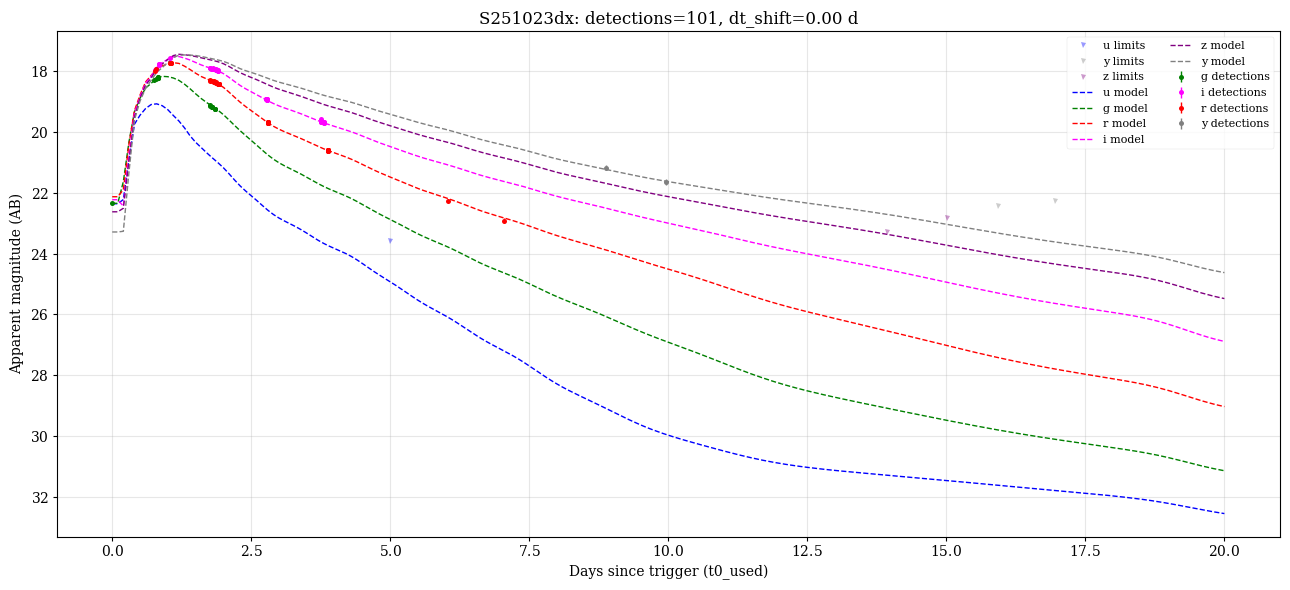


Success: reached 101 detections on attempt 1


In [28]:
rng_master = np.random.default_rng(RNG_SEED)

best = None
best_ndet = -1
last_err = None

event_t_start = time.monotonic()
attempt = 0

while attempt < MAX_ATTEMPTS:
    elapsed = time.monotonic() - event_t_start
    if elapsed > EVENT_TIME_LIMIT_SEC:
        print(f"Stopping after {elapsed:.2f} s because the event time limit was reached.")
        break

    attempt += 1

    if FIXED_T0 is not None:
        t0 = float(FIXED_T0)
    else:
        t0 = float(rng_master.uniform(float(t_min), float(t_max)))

    rng_attempt = np.random.default_rng(rng_master.integers(0, 2**32 - 1))

    try:
        redback_model = RedbackWrapperModel(
            source=bulla_bns_kilonova,
            parameters=params,
            ra=ra,
            dec=dec,
            distance=distance,
            t0=t0,
            node_label="source",
        )

        lcs = simulate_lightcurves(
            redback_model,
            1,
            obstable,
            passband_group,
            rng=rng_attempt,
        )

        ndet = count_detections_in_window(lcs.iloc[0])
        print(f"Attempt {attempt}: ndet = {ndet}")

        if ndet > best_ndet:
            attempt_meta = {
                "attempt": attempt,
                "t0_sim_mjd": t0,
                "ndet_window": ndet,
                "event_elapsed_sec": round(time.monotonic() - event_t_start, 3),
            }

            res = build_true_and_obs_and_plot(
                lightcurves_row=lcs.iloc[0],
                params=params,
                out_prefix=out_prefix,
                idx_label=idx_label,
                attempt_meta=attempt_meta,
            )

            best_ndet = ndet
            best = {
                "attempt": attempt,
                "t0_sim_mjd": t0,
                "result": res,
            }

        if ndet >= MIN_DETECTIONS:
            print()
            print(f"Success: reached {ndet} detections on attempt {attempt}")
            break

    except AssertionError as e:
        print(f"Stopped: surrogate range error: {e}")
        break

    except Exception as e:
        last_err = f"{type(e).__name__}: {str(e)[:200]}"
        print(f"Attempt {attempt} failed: {last_err}")
        continue


## Final report



Best result:
{'attempt': 1, 't0_sim_mjd': 60971.29269833938, 'result': {'obs_csv': '/projects/bdws/npletskova1/git/Rubin_ToO_workshop/S251023dx_observe.csv', 'true_csv': '/projects/bdws/npletskova1/git/Rubin_ToO_workshop/S251023dx_true.csv', 'plot_png': '/projects/bdws/npletskova1/git/Rubin_ToO_workshop/S251023dx.png', 'n_obs_points': 106, 'n_detections': 101, 'dt_shift': 0.0, 't0_used': 60971.29269833938, 'attempt_meta': {'attempt': 1, 't0_sim_mjd': 60971.29269833938, 'ndet_window': 101, 'event_elapsed_sec': 8.365}}}

Saved outputs:
  observations: /projects/bdws/npletskova1/git/Rubin_ToO_workshop/S251023dx_observe.csv
  truth curves: /projects/bdws/npletskova1/git/Rubin_ToO_workshop/S251023dx_true.csv
  plot: /projects/bdws/npletskova1/git/Rubin_ToO_workshop/S251023dx.png


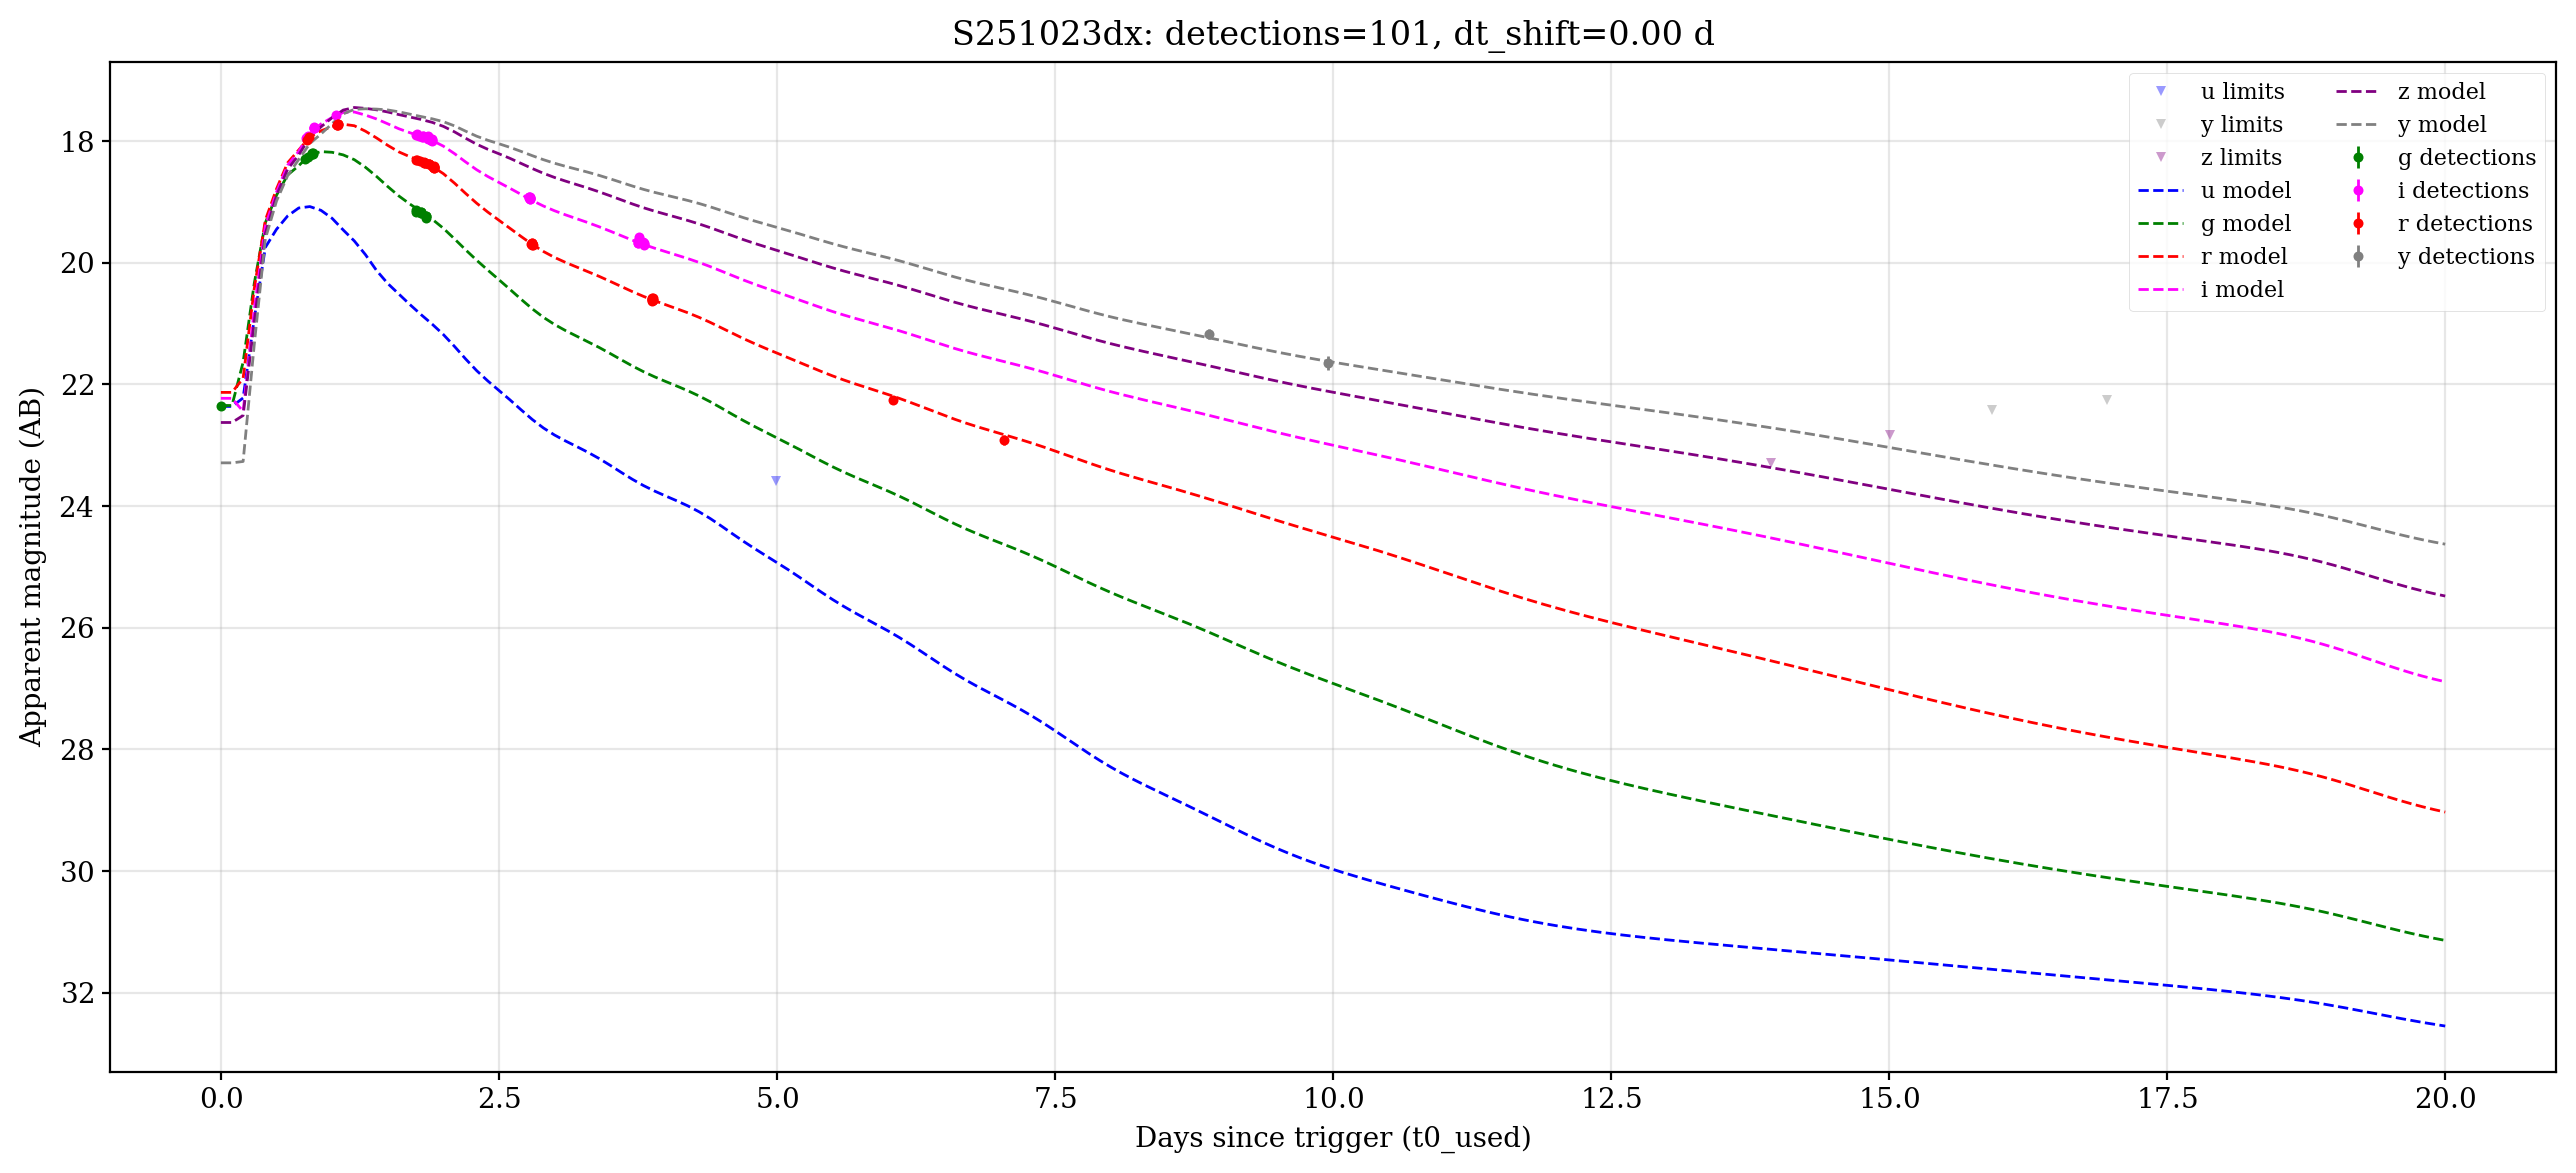

In [29]:
if best is not None:
    print("Best result:")
    print(best)
    print()
    print("Saved outputs:")
    print(f"  observations: {best['result']['obs_csv']}")
    print(f"  truth curves: {best['result']['true_csv']}")
    print(f"  plot: {best['result']['plot_png']}")
    display(Image(filename=best["result"]["plot_png"]))
else:
    print("No successful simulation produced.")
    if last_err is not None:
        print(f"Last error: {last_err}")
